In [ ]:
import sys, torch
# CHANGE THIS TO YOUR PATH TO THE REPO
ROOT = '/home/mdnikolaev/philurame/SDXL_SPEEDUP'
sys.path.append(ROOT)
from main_generate import construct_pipeline

# SDXL

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

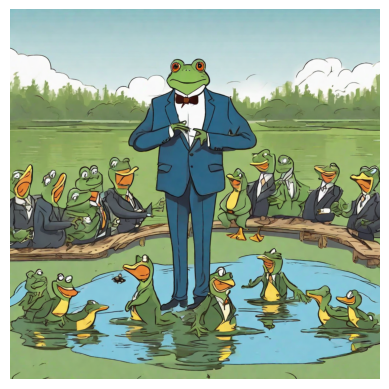

In [19]:
pipe = construct_pipeline(
  model_name = 'BASE',
  solver     = 'DEIS', 
  scheduler  = 'LINEAR',
)

img = pipe(
  'A frog in a suit giving a motivational speech at a pond, to an audience of ducks', 
  guidance_scale=5,
  num_inference_steps = 80,
  generator = torch.Generator(device='cpu').manual_seed(1),
  output_type='img'
).cpu()

import matplotlib.pyplot as plt
plt.imshow(img.squeeze().permute(1,2,0)), plt.axis('off');

# CIFAR

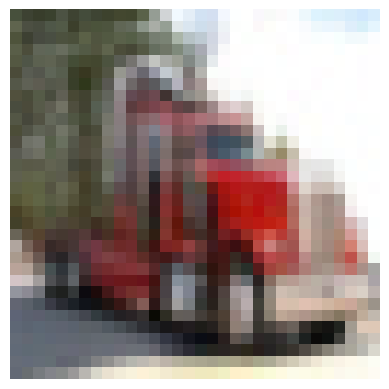

In [25]:
pipe = construct_pipeline(
  model_name = 'EDM',
  solver     = 'DDIM', 
  scheduler  = 'LINEAR',
)

img = pipe(
  num_inference_steps = 80,
  generator = torch.Generator(device='cpu').manual_seed(1),
).cpu()

import matplotlib.pyplot as plt
plt.imshow((img*127.5+128).clip(0,255).to(torch.uint8).squeeze().permute(1,2,0)), plt.axis('off');